# Ablation: calibration fraction

Sweeps `CALIBRATION_FRACTION` over a grid to measure how much the calibration fraction
affects classifier F1-score on experiments that use synthetic IMU.

`fraction=0.0` means **no calibration** — the raw geometrically-aligned signal is used as-is.
All other fractions apply per-fold percentile calibration using the first N% of each training
clip's real `imu.npz` as reference.

Only experiments that depend on synthetic IMU are run:
`imu_only_s2r`, `imu_only_mixed2r`, `vision_imu_s2r`, `vision_imu_mixed2r`.

You must use the `pose_module` kernel for this notebook.

In [1]:
from pathlib import Path
import sys
import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / 'pose_module').exists() and (root / 'evaluation').exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.classifiers import (
    WindowedDatasetConfig,
    build_classifier_capture_table,
    build_windowed_multimodal_dataset
)

from evaluation.classifiers import (
    EXPERIMENT_SPECS,
    ModelConfig,
    SplitConfig,
    TrainingConfig,
    run_experiment_suite
)

from pose_module.robot_emotions.metadata import get_protocol_info

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 260)
PROJECT_ROOT

PosixPath('/home/henriquesouza/POSE2IMU-Framework')

## Experiment Configuration

- `REAL_OUTPUT_ROOT` — real pipeline output directory (contains `virtual_imu_manifest.jsonl` + `imu.npz` per clip)
- `SYNTHETIC_MANIFEST` — manifest generated by `export-kimodo-virtual-imu`
- `MIXED_MANIFEST` — manifest generated by `export-mixed-virtual-imu`

In [2]:
REAL_OUTPUT_ROOT     = PROJECT_ROOT / 'output' / 'robot_emotions_virtual_imu'
SYNTHETIC_MANIFEST   = PROJECT_ROOT / 'output' / 'robot_emotions_kimodo_imu'  / 'virtual_imu_manifest.jsonl'
MIXED_MANIFEST       = PROJECT_ROOT / 'output' / 'robot_emotions_mixed_imu'   / 'mixed_virtual_imu_manifest.jsonl'
ANCHOR_CATALOG       = PROJECT_ROOT / 'output' / 'robot_emotions_kimodo_anchors' / 'kimodo_anchor_catalog.jsonl'

# Ablation results are cached here so the sweep can be skipped on reload.
# Delete this file to force a full re-run.
RESULTS_CACHE_PATH = PROJECT_ROOT / 'output' / 'ablation_calibration_results.pkl'

IMU_FEATURE_MODE = 'acc_euler'

# Grid of calibration fractions to sweep.
# 0.0 = no calibration (raw geometrically-aligned signal).
# >0.0 = first N% of each training clip's real imu.npz used as percentile reference.
CALIBRATION_FRACTIONS = [0.0, 0.1, 0.2, 0.5, 1.0]

# All experiments are run for completeness; those that don't use synthetic IMU
# produce identical results across fractions (calibration is a no-op for them).
# The plot will only show experiments that are actually affected by calibration.
SYNTHETIC_EXPERIMENT_NAMES = ['imu_only_s2r', 'imu_only_mixed2r', 'vision_imu_s2r', 'vision_imu_mixed2r']

EXCLUDED_EMOTIONS = {'Fear', 'Anger'}
EXCLUDED_STIMULI  = {}

DATASET_CONFIG = WindowedDatasetConfig(
    window_size=81,
    overlap=0.5,
    synthetic_variant='raw',
    imu_feature_mode=IMU_FEATURE_MODE,
    selected_sensors=None,
    max_windows_per_capture=None,
    random_state=42
)

SPLIT_CONFIG    = SplitConfig(n_splits=5, random_state=42)
MODEL_CONFIG    = ModelConfig(hidden_dim=128, dropout=0.1, trunk_blocks=2, modality_dropout_p=0.1)
TRAINING_CONFIG = TrainingConfig(
    batch_size=64, max_epochs=10, learning_rate=2e-3, weight_decay=1e-4,
    device='cuda',
    domain_loss_weight=0.1, flat_tag_loss_weight=0.3, emotion_loss_weight=1.0,
    modality_loss_weight=0.3, stimulus_loss_weight=0.3, use_cb_focal=False,
    show_progress=False,
)

print('REAL_OUTPUT_ROOT:', REAL_OUTPUT_ROOT)
print('SYNTHETIC_MANIFEST:', SYNTHETIC_MANIFEST)
print('MIXED_MANIFEST:', MIXED_MANIFEST)
print('ANCHOR_CATALOG:', ANCHOR_CATALOG)
print('CALIBRATION_FRACTIONS:', CALIBRATION_FRACTIONS)
print('RESULTS_CACHE_PATH:', RESULTS_CACHE_PATH)

REAL_OUTPUT_ROOT: /home/henriquesouza/POSE2IMU-Framework/output/robot_emotions_virtual_imu
SYNTHETIC_MANIFEST: /home/henriquesouza/POSE2IMU-Framework/output/robot_emotions_kimodo_imu/virtual_imu_manifest.jsonl
MIXED_MANIFEST: /home/henriquesouza/POSE2IMU-Framework/output/robot_emotions_mixed_imu/mixed_virtual_imu_manifest.jsonl
ANCHOR_CATALOG: /home/henriquesouza/POSE2IMU-Framework/output/robot_emotions_kimodo_anchors/kimodo_anchor_catalog.jsonl
CALIBRATION_FRACTIONS: [0.0, 0.1, 0.2, 0.5, 1.0]
RESULTS_CACHE_PATH: /home/henriquesouza/POSE2IMU-Framework/output/ablation_calibration_results.pkl


## Helpers for loading synthetic manifests

The synthetic manifest lacks `domain`/`user_id`/`tag_number` — these fields come from the real manifest
via `reference_clip_id`. The function below builds a capture table compatible with
`build_windowed_multimodal_dataset`.

In [3]:
def _load_real_manifest_index(real_output_root):
    """Load real manifest and index by clip_id for metadata lookup."""
    path = real_output_root / 'virtual_imu_manifest.jsonl'
    rows = []
    for line in path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        clip_dir = str(Path(e['artifacts']['virtual_imu_npz_path']).parent.parent.parent.resolve())
        rows.append({
            'clip_id':      str(e['clip_id']),
            'domain':       str(e['domain']),
            'user_id':      int(e['user_id']),
            'tag_number':   int(e['tag_number']),
            'take_id':      e.get('take_id'),
            'clip_dir':     clip_dir
        })
    return pd.DataFrame(rows).set_index('clip_id')

def _load_anchor_catalog_index(anchor_catalog_path):
    """Index anchor catalog by window_id → (start_sec, end_sec)."""
    index = {}
    for line in anchor_catalog_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        wid = e.get('window_id') or e.get('prompt_id')
        if wid and 'window' in e and e['window']:
            index[wid] = (float(e['window']['start_sec']), float(e['window']['end_sec']))
    return index

def _build_synthetic_capture_table(manifest_path, real_index, anchor_index, *, pose_kind_filter=None):
    """
    Build capture table from a synthetic or mixed manifest.

    emotion/modality/stimulus come from get_protocol_info(domain, tag_number).

    Extra fields for per-fold recalibration:
      - virtual_imu_uncalibrated_npz_path: geometrically-aligned, pre-calibration signal.
        For synthetic entries this is virtual_imu_npz_path (the Kimodo pipeline no longer
        applies percentile calibration globally). For pose_kind='real' entries this is
        virtual_imu_geometric_aligned_npz_path from the real pipeline artifacts.
      - real_imu_reference_npz_path: imu.npz of the reference real clip,
        used to build the reference matrix restricted to training subjects.
    """
    rows = []
    for line in manifest_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        if e.get('status') not in ('ok', 'warning'):
            continue
        pose_kind = e.get('pose_kind', 'synthetic')
        if pose_kind_filter is not None and pose_kind != pose_kind_filter:
            continue

        if pose_kind == 'real':
            artifacts = e.get('artifacts', {})
            pose3d_npz = artifacts.get('pose3d_npz_path')
            virtual_imu_npz = artifacts.get('virtual_imu_npz_path')
            uncalibrated_npz = artifacts.get('virtual_imu_geometric_aligned_npz_path')
            ref_clip_id = str(e['clip_id'])
        else:
            va = e.get('virtual_imu_artifacts', {})
            pose3d_npz = va.get('pose3d_npz_path')
            virtual_imu_npz = va.get('virtual_imu_npz_path')
            # virtual_imu_npz_path is geometrically aligned but not calibrated —
            # the Kimodo export pipeline saves the pre-calibration signal here.
            uncalibrated_npz = va.get('virtual_imu_npz_path')
            ref_clip_id = str(e.get('reference_clip_id') or e.get('clip_id'))

        if pose3d_npz is None or virtual_imu_npz is None:
            continue
        if not Path(pose3d_npz).exists() or not Path(virtual_imu_npz).exists():
            continue
        if ref_clip_id not in real_index.index:
            continue

        real_row = real_index.loc[ref_clip_id]
        real_imu_ref_path = str(Path(real_row['clip_dir']) / 'imu.npz')

        protocol = get_protocol_info(real_row['domain'], real_row['tag_number']) or {}
        emotion  = str(protocol.get('emotion', ''))
        modality = str(protocol.get('modality', ''))
        stimulus = str(protocol.get('stimulus', 'None'))

        window_id = e.get('window_id')
        real_imu_time_range_sec = anchor_index.get(window_id) if window_id else None

        sample_id = str(e.get('sample_id') or e.get('prompt_id') or e['clip_id'])
        rows.append({
            'clip_id':                            sample_id,
            'reference_clip_id':                  ref_clip_id,
            'domain':                             real_row['domain'],
            'user_id':                            real_row['user_id'],
            'tag_number':                         real_row['tag_number'],
            'take_id':                            real_row['take_id'],
            'emotion':                            emotion,
            'modality':                           modality,
            'stimulus':                           stimulus,
            'status':                             str(e.get('status', 'ok')),
            'pose3d_npz_path':                    pose3d_npz,
            'virtual_imu_npz_path':               virtual_imu_npz,
            'virtual_imu_uncalibrated_npz_path':  uncalibrated_npz,
            'real_imu_reference_npz_path':        real_imu_ref_path,
            'virtual_imu_frame_aligned_npz_path': None,
            'clip_dir':                           real_row['clip_dir'],
            'pose_kind':                          pose_kind,
            'quality_report':                     {},
            'real_imu_time_range_sec':            real_imu_time_range_sec
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df['subject_group'] = df.apply(lambda r: f"{r['domain']}_user_{int(r['user_id']):02d}", axis=1)
    df['flat_tag'] = df.apply(lambda r: f"{r['emotion']}|{r['modality']}|{r['stimulus']}", axis=1)
    df['frame_aligned_available'] = False
    n_with_range = df['real_imu_time_range_sec'].notna().sum()
    print(f'  real_imu_time_range_sec preenchido: {n_with_range}/{len(df)} amostras')
    n_uncal = df['virtual_imu_uncalibrated_npz_path'].notna().sum()
    print(f'  virtual_imu_uncalibrated_npz_path preenchido: {n_uncal}/{len(df)} amostras')
    return df.reset_index(drop=True)

def _apply_exclusions(df: pd.DataFrame, excluded_emotions: set[str], excluded_stimuli: set[str]) -> pd.DataFrame:
    """Remove captures whose emotions or stimuli are in the exclusion lists."""
    if df.empty:
        return df
    mask = pd.Series(False, index=df.index)
    if excluded_emotions:
        emotion_mask = df['emotion'].isin(excluded_emotions)
        if emotion_mask.any():
            print(f'  Excluindo {int(emotion_mask.sum())} capturas com emoção em {excluded_emotions}')
        mask |= emotion_mask
    if excluded_stimuli:
        stimulus_mask = df['stimulus'].isin(excluded_stimuli)
        if stimulus_mask.any():
            print(f'  Excluindo {int(stimulus_mask.sum())} capturas com estímulo em {excluded_stimuli}')
        mask |= stimulus_mask
    return df.loc[~mask].reset_index(drop=True)

def _sort_suite_summary(summary_df: pd.DataFrame) -> pd.DataFrame:
    order_map = {name: idx for idx, name in enumerate(REQUESTED_ORDER)}
    df = summary_df.copy()
    df['_sort_key'] = df['experiment_name'].astype(str).map(order_map).fillna(len(REQUESTED_ORDER))
    return df.sort_values('_sort_key', kind='stable').drop(columns=['_sort_key']).reset_index(drop=True)


def _run_pose_experiment(label: str, captures_df: pd.DataFrame) -> dict:
    """Build dataset and run classifier suite for a capture table."""
    captures_df = _apply_exclusions(captures_df, EXCLUDED_EMOTIONS, EXCLUDED_STIMULI)

    display(Markdown(f'### {label} — dataset'))
    display(captures_df[['clip_id', 'domain', 'user_id', 'tag_number', 'emotion', 'modality', 'stimulus', 'status']].head())
    print({'num_captures': len(captures_df), 'domains': sorted(captures_df['domain'].unique().tolist())})

    dataset_bundle = build_windowed_multimodal_dataset(REAL_OUTPUT_ROOT, config=DATASET_CONFIG, captures_df=captures_df)
    display(dataset_bundle['metadata'].head())
    display(dataset_bundle['alignment_summary'].head())
    print({
        'num_samples':          len(dataset_bundle['metadata']),
        'pose_shape':           dataset_bundle['pose_windows'].shape,
        'imu_real_shape':       dataset_bundle['imu_real_windows'].shape,
        'imu_synthetic_shape':  dataset_bundle['imu_synthetic_windows'].shape
    })

    display(Markdown(f'### {label} — suite de classificadores'))
    suite_result = run_experiment_suite(
        dataset_bundle,
        experiment_names=list(EXPERIMENT_SPECS.keys()),
        split_config=SPLIT_CONFIG,
        model_config=MODEL_CONFIG,
        training_config=TRAINING_CONFIG
    )
    display(_sort_suite_summary(suite_result['summary']))
    display(suite_result['domain_gap_summary'])
    return {'label': label, 'dataset_bundle': dataset_bundle, 'suite_result': suite_result}


REAL_INDEX = _load_real_manifest_index(REAL_OUTPUT_ROOT)
ANCHOR_INDEX = _load_anchor_catalog_index(ANCHOR_CATALOG)
print(f'Real manifest index: {len(REAL_INDEX)} clips')
print(f'Anchor catalog index: {len(ANCHOR_INDEX)} windows')

Real manifest index: 89 clips
Anchor catalog index: 3725 windows


---
## Per-fold synthetic IMU recalibration

For experiments with synthetic data (`imu_only_s2r`, `imu_only_mixed2r` and vision variants),
`_run_pose_experiment_fold_calibrated` applies percentile calibration per fold:

- The starting signal is always the **geometrically-aligned, pre-calibration** signal:
  - **Synthetic/Kimodo entries**: `virtual_imu_npz_path` from the Kimodo manifest (the export
    pipeline saves the pre-calibration signal here directly).
  - **Real-pipeline entries** (both `real_pose` and the real subset of `mixed`):
    `virtual_imu_geometric_aligned_npz_path` from the real manifest artifacts, exposed via
    `virtual_imu_uncalibrated_npz_path` in the capture table.
- Before each fold, the reference distribution is built exclusively from the `imu.npz` files
  of **training subjects**, eliminating leakage from test-set distributions.

This makes all three pipelines symmetric: every entry enters the classifier with geometric
alignment applied and calibration deferred to fold time.

In [4]:
from evaluation.classifiers.experiments import (
    build_subject_group_splits,
    run_single_experiment,
    _aggregate_oof_report,
    _build_oof_summary,
)
from evaluation.classifiers.metrics import (
    build_scored_class_ids,
    build_support_report,
    compute_domain_gap_summary,
    suite_results_frame,
    PRIMARY_HEADS,
)
from pose_module.processing.imu_calibration import build_calibration_reference_matrix, calibrate_virtual_imu_sequence
from evaluation.classifiers.features import build_imu_feature_tensor, resolve_imu_orientation_features
from evaluation.tsne import segment_signal_windows


def _build_train_real_imu_matrix(
    dataset_bundle: dict,
    train_capture_ids: set[str],
    *,
    calibration_fraction: float,
) -> np.ndarray:
    capture_table = dataset_bundle['capture_table']
    train_rows = capture_table[capture_table['clip_id'].isin(train_capture_ids)]

    seen_paths: set[str] = set()
    clip_npz_paths = []
    for _, row in train_rows.iterrows():
        ref_path = row.get('real_imu_reference_npz_path')
        if not ref_path or not Path(ref_path).exists():
            candidate = Path(row['clip_dir']) / 'imu.npz'
            if not candidate.exists():
                continue
            ref_path = str(candidate)
        if ref_path in seen_paths:
            continue
        seen_paths.add(ref_path)
        clip_npz_paths.append(ref_path)

    if not clip_npz_paths:
        raise RuntimeError('No training clip with a valid imu.npz found.')

    return build_calibration_reference_matrix(
        clip_npz_paths=clip_npz_paths,
        target_sensor_names=dataset_bundle['selected_sensors'],
        signal_mode='acc',
        calibration_fraction=calibration_fraction,
    )


def _recalibrate_synthetic_windows(
    dataset_bundle: dict,
    train_indices: np.ndarray,
    *,
    calibration_fraction: float,
) -> np.ndarray:
    """
    Rebuild imu_synthetic_windows applying percentile calibration restricted to
    training subjects.

    calibration_fraction=0.0 → skip calibration entirely, return the original windows.
    calibration_fraction>0.0 → use first N% of each training clip's imu.npz as reference.
    """
    import tempfile, os

    imu_synthetic = np.array(dataset_bundle['imu_synthetic_windows'], dtype=np.float32)

    if calibration_fraction == 0.0:
        return imu_synthetic  # no calibration

    metadata       = dataset_bundle['metadata']
    capture_table  = dataset_bundle['capture_table']
    imu_feature_mode = dataset_bundle['imu_feature_mode']
    selected_sensors = dataset_bundle['selected_sensors']
    cfg = dataset_bundle['config']

    train_capture_ids = set(metadata.iloc[train_indices]['capture_id'].astype(str).tolist())
    real_matrix = _build_train_real_imu_matrix(
        dataset_bundle, train_capture_ids, calibration_fraction=calibration_fraction
    )

    tmp = tempfile.NamedTemporaryFile(suffix='.npz', delete=False)
    tmp.close()
    try:
        # real_matrix is [N, S*3] (acc only); save as acc [N, S, 3] so
        # _extract_reference_signal picks the "acc" branch (not "imu" which needs 6 channels).
        np.savez(tmp.name,
                 acc=real_matrix.reshape(real_matrix.shape[0], len(selected_sensors), 3),
                 sensor_names=np.array(selected_sensors))

        cap_idx = capture_table.set_index('clip_id')

        for capture_id, window_indices in metadata.groupby('capture_id').groups.items():
            capture_id = str(capture_id)
            if capture_id not in cap_idx.index:
                continue
            cap_row = cap_idx.loc[capture_id]
            uncalibrated_path = cap_row.get('virtual_imu_uncalibrated_npz_path')
            if not uncalibrated_path or pd.isna(uncalibrated_path) or not Path(uncalibrated_path).exists():
                continue

            with np.load(uncalibrated_path, allow_pickle=True) as payload:
                raw_acc          = np.asarray(payload['acc'],            dtype=np.float32)
                raw_gyro         = np.asarray(payload['gyro'],           dtype=np.float32)
                timestamps_sec   = np.asarray(payload['timestamps_sec'], dtype=np.float32)
                sensor_names_raw = [str(v) for v in np.asarray(payload['sensor_names']).tolist()]

            sel_indices = [sensor_names_raw.index(s) for s in selected_sensors if s in sensor_names_raw]
            if len(sel_indices) != len(selected_sensors):
                continue
            acc_sel  = raw_acc[:,  sel_indices, :]
            gyro_sel = raw_gyro[:, sel_indices, :]

            from pose_module.interfaces import VirtualIMUSequence
            seq = VirtualIMUSequence(
                clip_id=capture_id,
                fps=None,
                sensor_names=selected_sensors,
                acc=acc_sel,
                gyro=gyro_sel,
                timestamps_sec=timestamps_sec,
                source='uncalibrated',
            )
            result = calibrate_virtual_imu_sequence(
                seq,
                real_imu_reference_path=tmp.name,
                signal_mode='acc',
            )
            calibrated_acc = np.asarray(result['virtual_imu_sequence'].acc, dtype=np.float32)

            imu_features = build_imu_feature_tensor(
                calibrated_acc, gyro_sel, timestamps_sec, feature_mode=imu_feature_mode
            )
            window_bundle = segment_signal_windows(
                imu_features['values'],
                window_type='n_samples',
                window_size=int(cfg.window_size),
                stride_or_overlap_mode='overlap',
                overlap=float(cfg.overlap)
            )
            new_windows = np.asarray(window_bundle['windows'], dtype=np.float32)

            window_idx_array = np.asarray(window_indices, dtype=np.int64)
            n_replace = min(len(window_idx_array), new_windows.shape[0])
            imu_synthetic[window_idx_array[:n_replace]] = new_windows[:n_replace]
    finally:
        os.unlink(tmp.name)

    return imu_synthetic


def _run_ablation_fold_calibrated(
    label: str,
    captures_df: pd.DataFrame,
    *,
    calibration_fraction: float,
    experiment_names: list[str],
) -> dict:
    """
    Run classifier suite for one calibration_fraction value.

    calibration_fraction=0.0 → no calibration applied (raw signal).
    """
    captures_df = _apply_exclusions(captures_df, EXCLUDED_EMOTIONS, EXCLUDED_STIMULI)

    dataset_bundle = build_windowed_multimodal_dataset(REAL_OUTPUT_ROOT, config=DATASET_CONFIG, captures_df=captures_df)

    splits = build_subject_group_splits(dataset_bundle['metadata'], config=SPLIT_CONFIG)
    support_report = build_support_report(
        dataset_bundle['metadata'],
        dataset_bundle['label_encoders'],
        group_column=str(SPLIT_CONFIG.group_column),
        min_subject_groups=int(SPLIT_CONFIG.min_subject_groups_per_class)
    )
    scored_class_ids = build_scored_class_ids(support_report, head_names=PRIMARY_HEADS)

    results = []
    for split in splits:
        fold_id      = int(split['split_id'])
        train_indices = np.asarray(split['train_indices'], dtype=np.int64)

        recalibrated_synthetic = _recalibrate_synthetic_windows(
            dataset_bundle, train_indices, calibration_fraction=calibration_fraction
        )
        fold_bundle = {**dataset_bundle, 'imu_synthetic_windows': recalibrated_synthetic}

        split_with_context = {**split, 'num_splits': len(splits)}
        for experiment_name in experiment_names:
            results.append(
                run_single_experiment(
                    fold_bundle,
                    experiment_name=experiment_name,
                    split=split_with_context,
                    model_config=MODEL_CONFIG,
                    training_config=TRAINING_CONFIG,
                    scored_class_ids=scored_class_ids
                )
            )

    results_frame = suite_results_frame(results)
    oof_reports = {
        exp: _aggregate_oof_report(
            [r for r in results if r['experiment_name'] == exp],
            label_encoders=dataset_bundle['label_encoders'],
            scored_class_ids=scored_class_ids
        )
        for exp in experiment_names
    }
    oof_summary = _build_oof_summary(
        oof_reports,
        support_report=support_report,
        primary_head=str(SPLIT_CONFIG.primary_head)
    )
    suite_result = {
        'results': results,
        'results_frame': results_frame,
        'summary': oof_summary,
        'oof_reports': oof_reports,
        'support_report': support_report,
        'domain_gap_summary': compute_domain_gap_summary(oof_summary),
        'splits': splits,
    }
    return {
        'label': label,
        'calibration_fraction': calibration_fraction,
        'dataset_bundle': dataset_bundle,
        'suite_result': suite_result,
    }

---
## Load capture tables and build dataset bundle

The dataset bundle is built once per capture set (synthetic / mixed) and reused
across all calibration fractions — only `imu_synthetic_windows` is rebuilt per fold.

In [5]:
REAL_INDEX   = _load_real_manifest_index(REAL_OUTPUT_ROOT)
ANCHOR_INDEX = _load_anchor_catalog_index(ANCHOR_CATALOG)
print(f'Real manifest index: {len(REAL_INDEX)} clips')
print(f'Anchor catalog index: {len(ANCHOR_INDEX)} windows')

CAPTURES_REAL = build_classifier_capture_table(REAL_OUTPUT_ROOT)
CAPTURES_SYNTHETIC = _build_synthetic_capture_table(
    SYNTHETIC_MANIFEST, REAL_INDEX, ANCHOR_INDEX, pose_kind_filter='synthetic'
)
CAPTURES_MIXED = _build_synthetic_capture_table(
    MIXED_MANIFEST, REAL_INDEX, ANCHOR_INDEX, pose_kind_filter=None
)
print(f'Real captures:      {len(CAPTURES_REAL)}')
print(f'Synthetic captures: {len(CAPTURES_SYNTHETIC)}')
print(f'Mixed captures:     {len(CAPTURES_MIXED)}')

Real manifest index: 89 clips
Anchor catalog index: 3725 windows
  real_imu_time_range_sec preenchido: 3722/3722 amostras
  virtual_imu_uncalibrated_npz_path preenchido: 3722/3722 amostras
  real_imu_time_range_sec preenchido: 3722/3811 amostras
  virtual_imu_uncalibrated_npz_path preenchido: 3811/3811 amostras
Real captures:      80
Synthetic captures: 3722
Mixed captures:     3811


---
## Ablation sweep

For each `calibration_fraction` in `CALIBRATION_FRACTIONS`, runs the classifier suite
on both the synthetic-only and mixed capture sets.
Results are collected in `ABLATION_RESULTS` for plotting.

In [6]:
ALL_EXPERIMENT_NAMES = list(EXPERIMENT_SPECS.keys())

CAPTURE_SETS = [
    ('real',      CAPTURES_REAL),
    ('synthetic', CAPTURES_SYNTHETIC),
    ('mixed',     CAPTURES_MIXED),
]

if RESULTS_CACHE_PATH.exists():
    print(f'Loading cached results from {RESULTS_CACHE_PATH}')
    with open(RESULTS_CACHE_PATH, 'rb') as f:
        ABLATION_RESULTS = pickle.load(f)
    print(f'Loaded {len(ABLATION_RESULTS)} entries.')
else:
    ABLATION_RESULTS = []

    for fraction in CALIBRATION_FRACTIONS:
        label = f'fraction={fraction:.2f}'
        print(f'\n{"="*60}')
        print(f'  calibration_fraction = {fraction}')
        print(f'{"="*60}')

        for pose_set_name, captures_df in CAPTURE_SETS:
            print(f'  >> {pose_set_name}_pose')
            res = _run_ablation_fold_calibrated(
                f'{pose_set_name}_pose | {label}',
                captures_df.copy(),
                calibration_fraction=fraction,
                experiment_names=ALL_EXPERIMENT_NAMES,
            )
            # Drop dataset_bundle before caching — it holds large numpy arrays
            # and can be rebuilt from the capture tables if needed.
            ABLATION_RESULTS.append({
                'label':                res['label'],
                'pose_set':             pose_set_name,
                'calibration_fraction': res['calibration_fraction'],
                'suite_result': {
                    k: v for k, v in res['suite_result'].items()
                    if k != 'results'  # raw per-fold results are large; summary is enough
                },
            })

    with open(RESULTS_CACHE_PATH, 'wb') as f:
        pickle.dump(ABLATION_RESULTS, f)
    print(f'\nAblation sweep complete. Results saved to {RESULTS_CACHE_PATH}')


  calibration_fraction = 0.0
  >> real_pose
  Excluindo 4 capturas com emoção em {'Fear', 'Anger'}
  >> synthetic_pose
  Excluindo 142 capturas com emoção em {'Fear', 'Anger'}
  >> mixed_pose
  Excluindo 146 capturas com emoção em {'Fear', 'Anger'}

  calibration_fraction = 0.1
  >> real_pose
  Excluindo 4 capturas com emoção em {'Fear', 'Anger'}
  >> synthetic_pose
  Excluindo 142 capturas com emoção em {'Fear', 'Anger'}
  >> mixed_pose
  Excluindo 146 capturas com emoção em {'Fear', 'Anger'}

  calibration_fraction = 0.2
  >> real_pose
  Excluindo 4 capturas com emoção em {'Fear', 'Anger'}
  >> synthetic_pose
  Excluindo 142 capturas com emoção em {'Fear', 'Anger'}
  >> mixed_pose
  Excluindo 146 capturas com emoção em {'Fear', 'Anger'}

  calibration_fraction = 0.5
  >> real_pose
  Excluindo 4 capturas com emoção em {'Fear', 'Anger'}
  >> synthetic_pose
  Excluindo 142 capturas com emoção em {'Fear', 'Anger'}
  >> mixed_pose
  Excluindo 146 capturas com emoção em {'Fear', 'Anger'}


---
## Results table

Full summary per fraction × pose_set × experiment.

In [7]:
rows = []
for res in ABLATION_RESULTS:
    for _, row in res['suite_result']['summary'].iterrows():
        rows.append({
            'pose_set':             res['pose_set'],
            'calibration_fraction': res['calibration_fraction'],
            'experiment_name':      row['experiment_name'],
            'emotion_macro_f1':     row.get('emotion_macro_f1'),
        })

ABLATION_TABLE = pd.DataFrame(rows)
display(ABLATION_TABLE.sort_values(['pose_set', 'experiment_name', 'calibration_fraction']))

,pose_set,calibration_fraction,experiment_name,emotion_macro_f1
15,mixed,0.0,imu_only_mixed2r,0.476942
39,mixed,0.1,imu_only_mixed2r,0.444171
58,mixed,0.2,imu_only_mixed2r,0.446345
79,mixed,0.5,imu_only_mixed2r,0.456734
98,mixed,1.0,imu_only_mixed2r,0.469201
...,...,...,...,...
11,synthetic,0.0,vision_only,0.431391
33,synthetic,0.1,vision_only,0.400819
53,synthetic,0.2,vision_only,0.410100
73,synthetic,0.5,vision_only,0.470335


---
## Plot: emotion macro-F1 vs calibration fraction

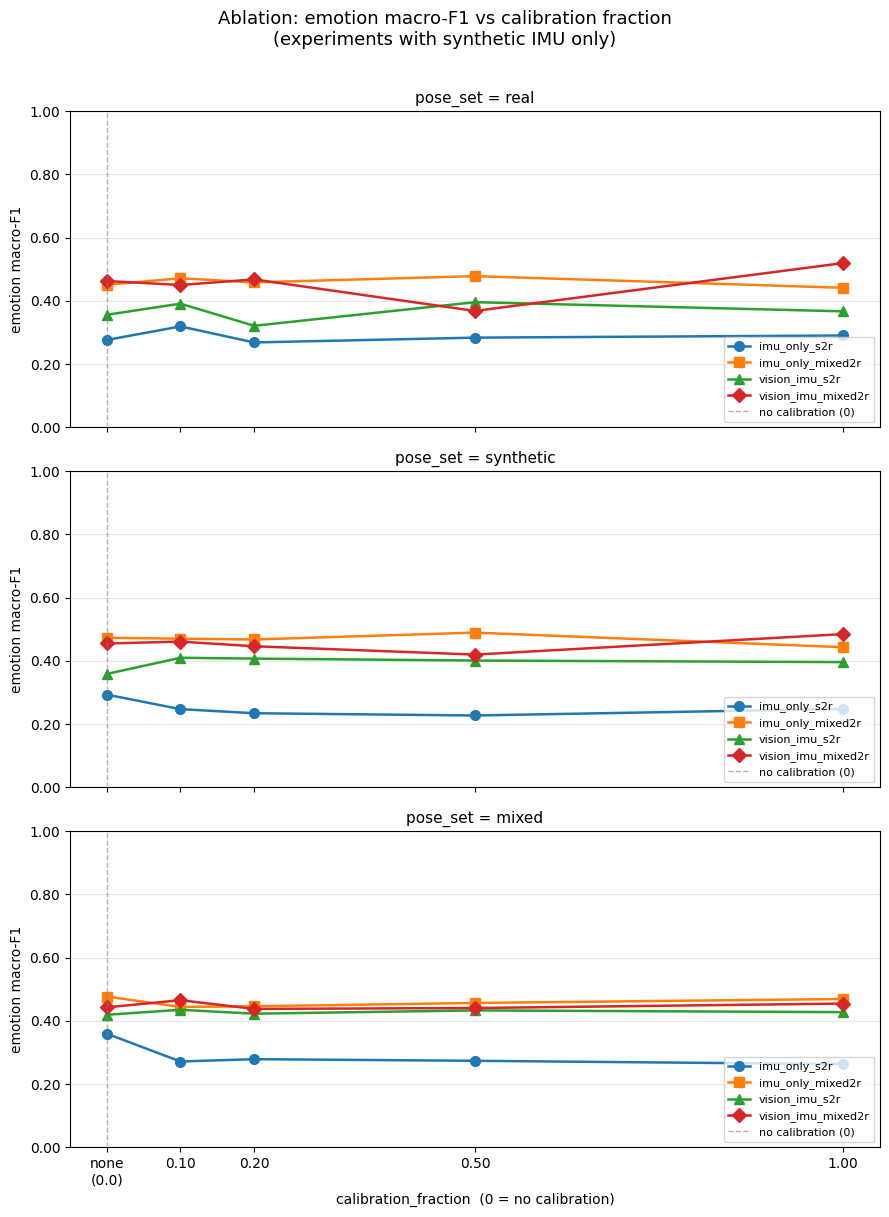

: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

POSE_SETS  = ['real', 'synthetic', 'mixed']
FRACTIONS  = sorted(ABLATION_TABLE['calibration_fraction'].unique().tolist())

# Only plot experiments whose results are actually affected by calibration.
PLOT_EXP_NAMES = SYNTHETIC_EXPERIMENT_NAMES

fig, axes = plt.subplots(
    len(POSE_SETS), 1,
    figsize=(9, 4 * len(POSE_SETS)),
    sharex=True,
    squeeze=False,
)

markers = ['o', 's', '^', 'D']
colors  = plt.rcParams['axes.prop_cycle'].by_key()['color']

for ax_row, pose_set in zip(axes, POSE_SETS):
    ax = ax_row[0]
    subset = ABLATION_TABLE[
        (ABLATION_TABLE['pose_set'] == pose_set) &
        (ABLATION_TABLE['experiment_name'].isin(PLOT_EXP_NAMES))
    ]

    for i, exp_name in enumerate(PLOT_EXP_NAMES):
        exp_data = subset[subset['experiment_name'] == exp_name].sort_values('calibration_fraction')
        if exp_data.empty:
            continue
        ax.plot(
            exp_data['calibration_fraction'],
            exp_data['emotion_macro_f1'],
            marker=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=exp_name,
            linewidth=1.8,
            markersize=7,
        )

    ax.axvline(x=0.0, color='grey', linestyle='--', linewidth=1, alpha=0.6, label='no calibration (0)')
    ax.set_title(f'pose_set = {pose_set}', fontsize=11)
    ax.set_ylabel('emotion macro-F1')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)

axes[-1][0].set_xlabel('calibration_fraction  (0 = no calibration)')
axes[-1][0].set_xticks(FRACTIONS)
axes[-1][0].set_xticklabels([('none\n(0.0)' if f == 0.0 else f'{f:.2f}') for f in FRACTIONS])

fig.suptitle('Ablation: emotion macro-F1 vs calibration fraction\n(experiments with synthetic IMU only)', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()